This page contains the instructions to access the satellite data from Copernicus Data Space Ecosystem, the annotations from Zenodo and creating computer vision datasets from them. Dataset conversions are done with [geo2ml](https://mayrajeo.github.io/geo2ml/).

In [ ]:
import os, sys
from pathlib import Path
import rasterio as rio
import rasterio.plot as rioplot
import rasterio.windows as riowindow
from rasterio.windows import Window
import matplotlib.pyplot as plt
from shapely.geometry import box, Polygon
import numpy as np
import geopandas as gpd
from itertools import product
import random
sys.path.insert(1, '..')
from src.colors import *

## Accessing the annotations

The manually annotated vessel data are stored in [10.5281/zenodo.10046341](https://zenodo.org/records/15019034) as GeoPackage files. Each gpkg file corresponds to a single tile location, and each layer in a gpkg corresponds to a specific date. 

The following mosaics were used as training and validation data.

|Location|Product name|Number of annotations|
|--------|------------|---------------------|
|Archipelago sea|S2A_MSIL1C_20220515T100031_N0400_R122_T34VEM_20220515T120450|183|
|Archipelago sea|S2B_MSIL1C_20220619T100029_N0400_R122_T34VEM_20220619T104419|519|
|Archipelago sea|S2A_MSIL1C_20220721T095041_N0400_R079_T34VEM_20220721T115325|1518|
|Archipelago sea|S2A_MSIL1C_20220813T095601_N0400_R122_T34VEM_20220813T120233|1371|
|Gulf of Finland|S2B_MSIL1C_20220606T095029_N0400_R079_T35VLG_20220606T105944|277|
|Gulf of Finland|S2B_MSIL1C_20220626T095039_N0400_R079_T35VLG_20220626T104321|1205|
|Gulf of Finland|S2B_MSIL1C_20220703T094039_N0400_R036_T35VLG_20220703T103953|746|
|Gulf of Finland|S2A_MSIL1C_20220721T095041_N0400_R079_T35VLG_20220721T115325|971|
|Bothnian Bay   |S2A_MSIL1C_20220627T100611_N0400_R022_T34WFT_20220627T134958|122|
|Bothnian Bay   |S2B_MSIL1C_20220712T100559_N0400_R022_T34WFT_20220712T121613|162|
|Bothnian Bay   |S2B_MSIL1C_20220828T095549_N0400_R122_T34WFT_20220828T104748|98|

The following mosaics were used as test data:

|Location|Product name|Number of annotations|
|--------|------------|---------------------|
|Bothnian sea|S2B_MSIL1C_20210714T100029_N0301_R122_T34VEN_20210714T121056|450|
|Bothnian sea|S2B_MSIL1C_20220619T100029_N0400_R122_T34VEN_20220619T104419|66|
|Bothnian sea|S2A_MSIL1C_20220624T100041_N0400_R122_T34VEN_20220624T120211|424|
|Bothnian sea|S2A_MSIL1C_20220813T095601_N0400_R122_T34VEN_20220813T120233|399|
|Kvarken|S2B_MSIL1C_20210714T100029_N0301_R122_T34VEN_20210714T121056|83|
|Kvarken|S2B_MSIL1C_20220712T100559_N0400_R022_T34VER_20220712T121613|184|
|Kvarken|S2A_MSIL1C_20220826T100611_N0400_R022_T34VER_20220826T135136|88|

## Accessing the satellite data

The easiest way to access Sentinel-2 products is with [Copernicus Data Space Ecosystem (CDSE)](https://documentation.dataspace.copernicus.eu/Registration.html). After registering, the data can be accessed via [Copernicus Browser](https://browser.dataspace.copernicus.eu/), or through different APIs (OData, STAC).

There are two scripts that can be used to download the data through OData API. In order to use them with `--creds_file` argument, create a following file somewhere safe to store the credentials:

```json
{
    "grant_type": "password",
    "username": "<your_use_email>",
    "password": "<password>",
    "client_id": "cdse-public"
}
```

[scripts/cdse_odata.py](https://github.com/mayrajeo/ship-detection/blob/main/scripts/cdse_odata.py) can be used to download the full Sentinel-2 product, whereas [scripts/cdse_odata_tci.py](https://github.com/mayrajeo/ship-detection/blob/main/scripts/cdse_odata_tci.py) downloads only the L1C-TCI image, provided it is available. Both scripts can be used like this:

```bash
python scripts/cdse_odata.py <S2_product_name>.SAFE --creds_file <path_to_creds_file> --target_path <where_to_download>
```

There are some cases where the L1C-TCI is not available. It can be constructed from the full product directory like this:

In [ ]:
import glob

SATURATION_VALUE = 3558

def make_tci_mosaic(input_safe:str, outfile:str):
    """Create a L1C-TCI mosaic from a .SAFE directory found from `input_safe`
    and save it to `outfile`
    """
    xmlroot = glob.glob(os.path.join(input, 'MTD_MSIL1C.xml'))[0]

    with rio.open(xmlroot, 'r') as src:
        data_10m = src.subdatasets[0]

    # Derive offset_value depending on the processing baseline
    baseline_ver = int(input.split('_')[-4][2:])
    if baseline_ver >= 400: RADIO_ADD_OFFSET = -1000
    else: RADIO_ADD_OFFSET = 0

    with rio.open(data_10m, 'r') as src:
        B04 = (src.read(1) + RADIO_ADD_OFFSET)/SATURATION_VALUE
        B03 = (src.read(2) + RADIO_ADD_OFFSET)/SATURATION_VALUE
        B02 = (src.read(3) + RADIO_ADD_OFFSET)/SATURATION_VALUE
        prof = src.profile

    r = np.clip(255*B04, 0, 255).astype(np.uint8)
    g = np.clip(255*B03, 0, 255).astype(np.uint8)
    b = np.clip(255*B02, 0, 255).astype(np.uint8)

    prof.update(
        count=3,
        dtype='uint8',
        driver='GTiff', 
        compress='lzw',
        predictor=2,
        BIGTIFF='YES'
    )

    print('Writing data')
    with rio.open(outfile, 'w', **prof) as dst:
        dst.write(np.stack([r, g, b]))

In this example, we use the product `S2A_MSIL1C_20220721T095041_N0400_R079_T34VEM_20220721T115325` to show how the data can be constructed. After registration to CDSE, download the data from either via Copernicus Browser or with

```bash
python scripts/cdse_odata_tci.py S2A_MSIL1C_20220721T095041_N0400_R079_T34VEM_20220721T115325.SAFE --creds_file <path_to_creds> --target_path <path_to_data>
```

## Visualizing the data

In [ ]:
data_path = Path('../l1c_tci/mosaics/S2A_MSIL1C_20220721T095041_N0400_R079_T34VEM_20220721T115325_TCI_10m.tif')
annotations = gpd.read_file('../dataset/34VEM.gpkg', layer='20220721')

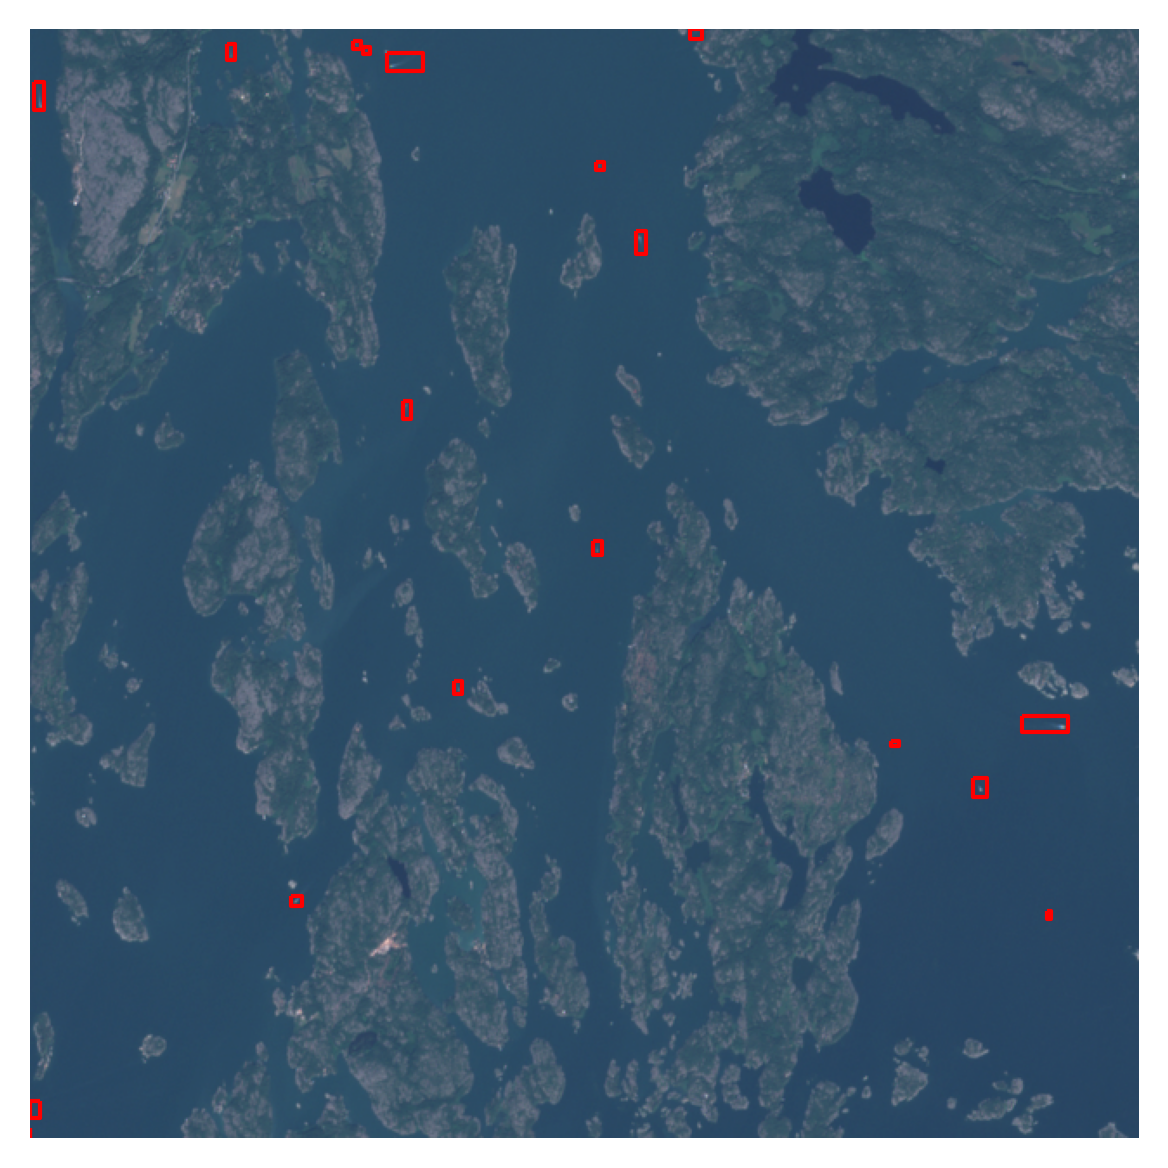

In [ ]:
bright = 1.5 # L1C-TCI are dark in the Finnish coast so brighten them
win = Window(8000,5000,640,640)

fig, ax = plt.subplots(1,1, dpi=300)
ax.axis('off')
with rio.open(data_path) as src:
    im = src.read(window=win)
    win_transform = src.window_transform(win)
    win_bounds = riowindow.bounds(win, src.transform)
    rioplot.show((im*bright).astype(int), transform=win_transform, ax=ax, vmin=100, vmax=255)

annotations.clip(box(*win_bounds)).plot(ax=ax, facecolor='none', edgecolor='red')
plt.show()

As the annotations are hand-drawn with QGis, they might not always be pixel-perfect. Typically there is a slight buffer around each side, and it can be tightened with the following function, if needed:

In [ ]:
def edge_coords(geom):
    "Tighten the bounds to S2 pixel edges"
    xmin, ymin, xmax, ymax = geom.bounds
    # xmin rounds up
    edge_xmin = np.ceil(xmin/10) * 10
    # ymin rounds up
    edge_ymin = np.ceil(ymin/10) * 10
    # xmax rounds down
    edge_xmax = np.floor(xmax/10) * 10
    # ymax rounds down
    edge_ymax = np.floor(ymax/10) * 10
    return box(edge_xmin, edge_ymin, edge_xmax, edge_ymax)

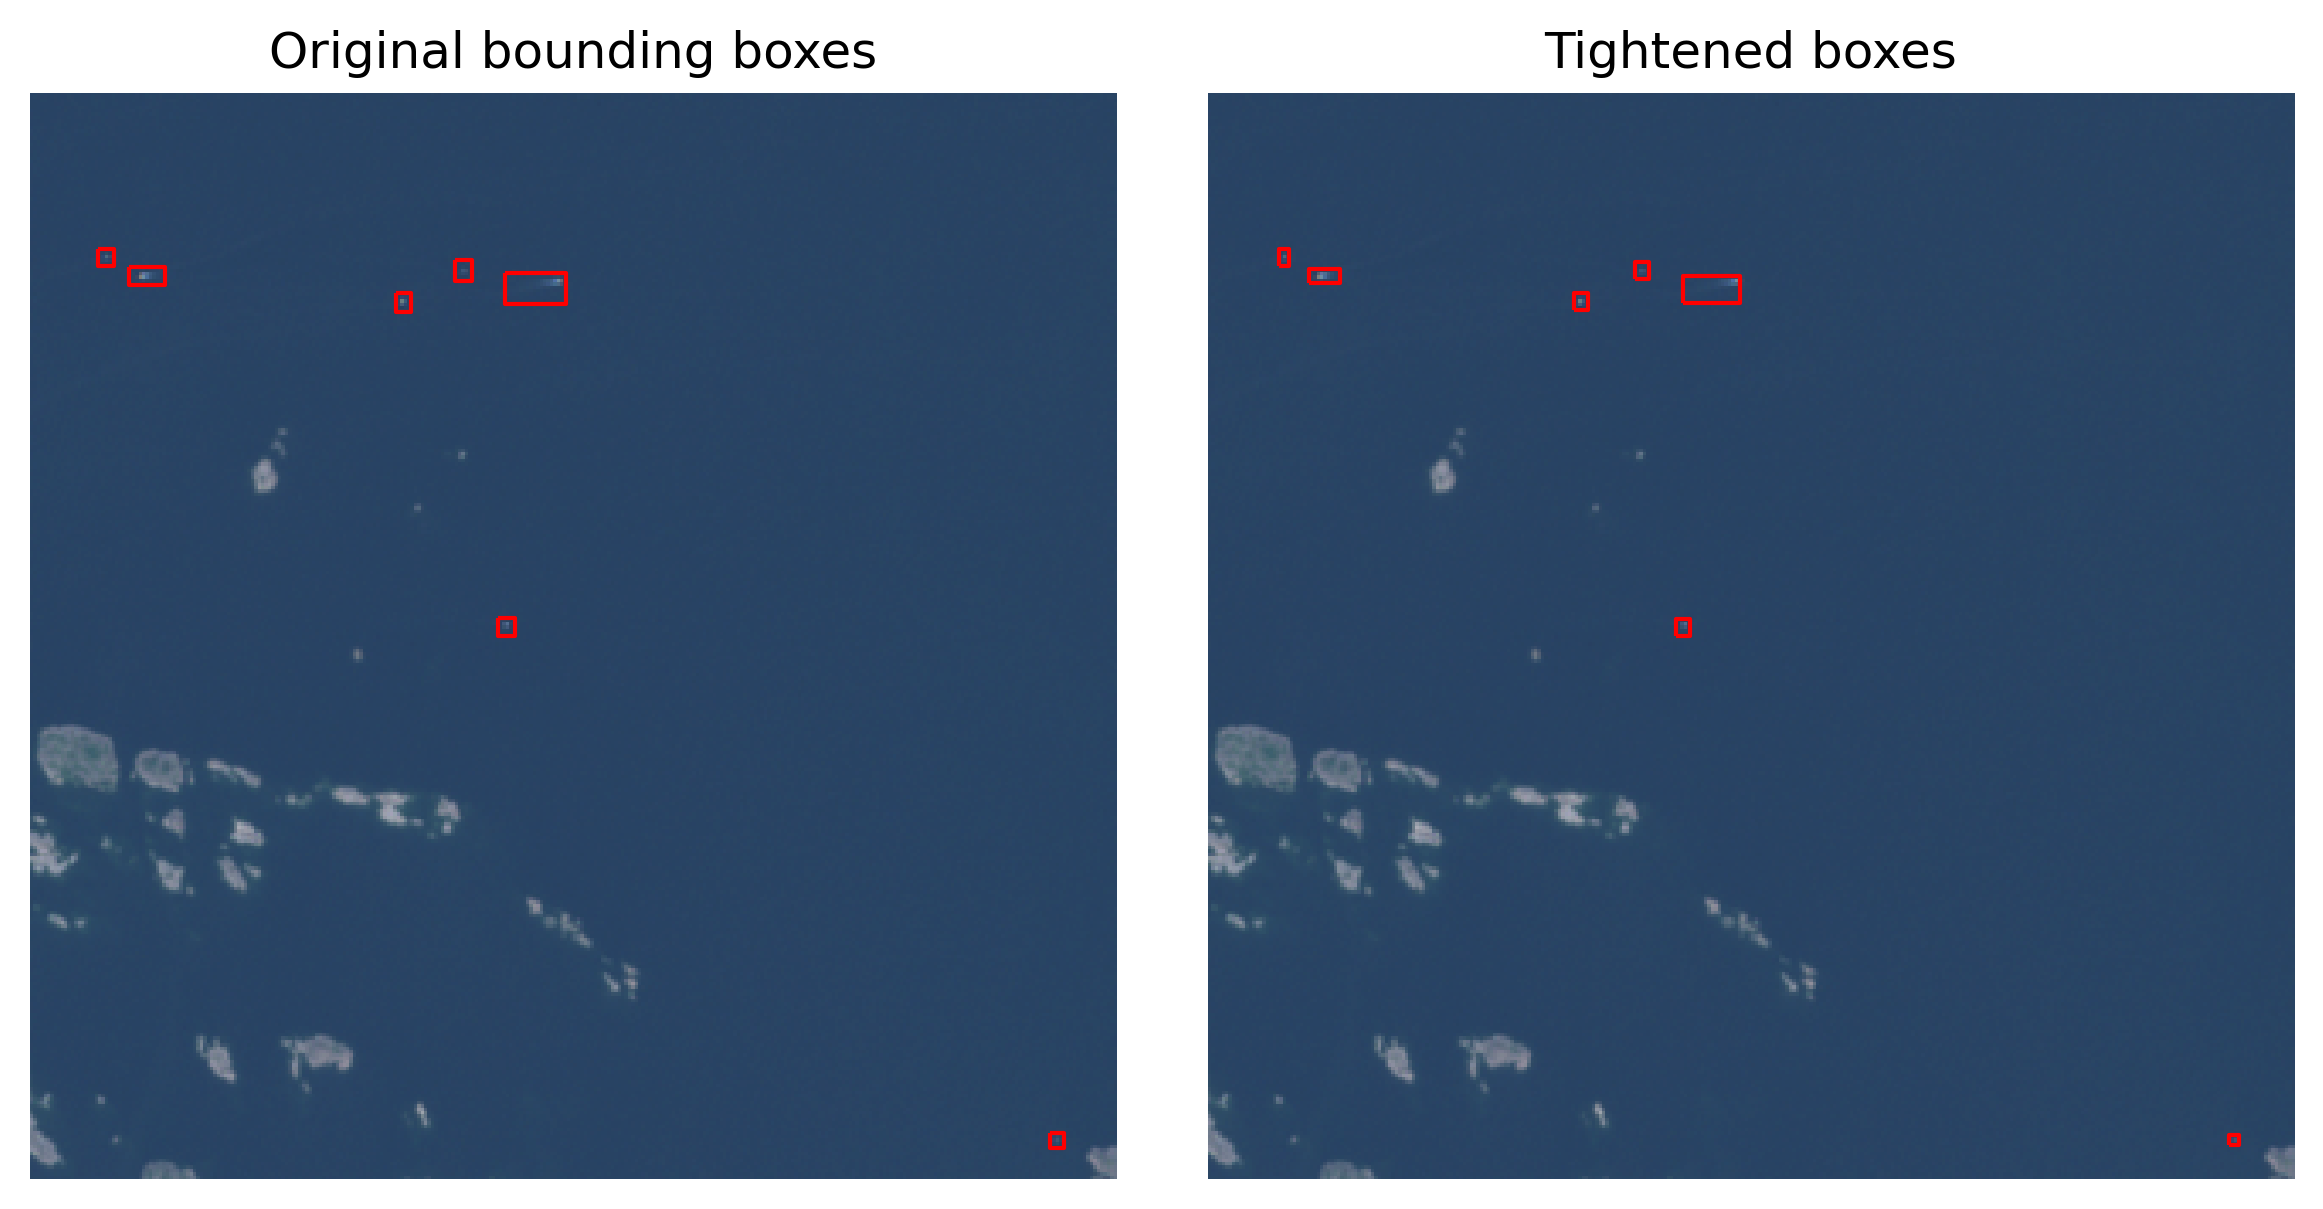

In [ ]:
annotations_tight = annotations.copy()
annotations_tight['geometry'] = annotations_tight.geometry.apply(edge_coords)

fig, axs = plt.subplots(1,2, figsize=(8,4), dpi=300)
win = Window(7000,6000,320,320)

for a in axs: a.axis('off')
    
with rio.open(data_path) as src:
    im = src.read(window=win)
    win_transform = src.window_transform(win)
    win_bounds = riowindow.bounds(win, src.transform)
    rioplot.show((im*bright).astype(int), transform=win_transform, ax=axs[0])
    rioplot.show((im*bright).astype(int), transform=win_transform, ax=axs[1])

annotations.clip(box(*win_bounds)).plot(ax=axs[0], facecolor='none', edgecolor='red')
annotations_tight.clip(box(*win_bounds)).plot(ax=axs[1], facecolor='none', edgecolor='red')
axs[0].set_title('Original bounding boxes')
axs[1].set_title('Tightened boxes')
plt.tight_layout()
plt.show()

Also, the annotations are done with different color adjustments easier for human experts to interpret, so some targets are extremely difficult to see. As computer vision models interpret the image differently, it is not that much of a problem for them.

## Computer vision dataset creation

There are a couple of ways to convert the geodata to YOLO format dataset with `geo2ml`. The scripts `create_yolo_dataset` and `create_coco_dataset` are straightforward utility functions that 

1) Split the raster data into smaller chips
2) Split the corresponding vector data into smaller files, each corresponding to a single chip
3) Convert the geo-annotations into specific dataset format

If there is a need to customize (e.g. dataset splits) the workflow, then [scripts/make_yolo_data.py](https://github.com/mayrajeo/ship-detection/blob/main/scripts/make_yolo_data.py) shows an example on how to do that. In this script, each mosaic are split into a grid, and the diagonal cells are used as validation data. Each of the train mosaics are split in this way, resulting into 80-20 spatial train-val-split.

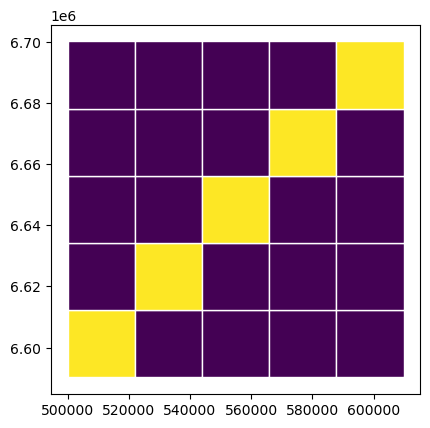

In [ ]:
def make_fold_grid(poly, num_edge, crs) -> gpd.GeoDataFrame:
    xmin, ymin, xmax, ymax = poly.bounds
    dx = (xmax-xmin)//num_edge
    dy = (ymax-ymin)//num_edge
    polys = []
    folds = []
    for x, y in product(range(0, num_edge), range(0, num_edge)):
        xm = xmin+x*dx
        ym = ymin+y*dy
        polys.append(box(*(xm, ym, xm+dx, ym+dy)))
        folds.append(f'fold_{(x-y)%num_edge + 1}')
    return gpd.GeoDataFrame(data={'fold': folds, 'geometry': polys}, crs=crs)

with rio.open(data_path) as src:
    bounds = src.bounds
    crs = src.crs

grid = make_fold_grid(box(*bounds), 5, crs)
grid['val'] = grid.fold.apply(lambda row: 1 if row == 'fold_1' else 0)
grid.plot(column='val', edgecolor='white')
plt.show()

### YOLO conversion

In [ ]:
from geo2ml.scripts.data import create_yolo_dataset

/home/mayrajeo/miniconda3/envs/ml-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The following creates a yolo dataset to `yolo_outpath`, along with the template for `dataset.yaml` file. 

In [ ]:
yolo_outpath = Path('example_data/yolo') # Outpath for the dataset
create_yolo_dataset(raster_path=data_path, polygon_path='../dataset/34VEM.gpkg', target_column='id', 
                    outpath=yolo_outpath, save_grid=False, gridsize_x=320, gridsize_y=320, 
                    ann_format='box', min_bbox_area=0, allow_partial_data=True, gpkg_layer='20220721')


1225it [01:05, 18.71it/s]
1225it [00:08, 138.54it/s]
/home/mayrajeo/miniconda3/envs/ml-env/lib/python3.11/site-packages/pyogrio/geopandas.py:265: UserWarning: More than one layer found in '34VEM.gpkg': '20220515' (default), '20220619', '20220721', '20220813'. Specify layer parameter to avoid this warning.
  result = read_func(
395it [00:22, 17.88it/s]


### COCO conversion

In [ ]:
from geo2ml.scripts.data import create_coco_dataset

The following creates a coco dataset to `coco_outpath`, with the complete `json` file containing all the information about the dataset.

In [ ]:
coco_outpath = Path('example_data/coco') # Outpath for the dataset
create_coco_dataset(raster_path=data_path, polygon_path='../dataset/34VEM.gpkg', target_column='id', 
                    outpath=coco_outpath, save_grid=False, gridsize_x=320, gridsize_y=320, dataset_name='34VEN_20220721',
                    ann_format='box', min_bbox_area=0, allow_partial_data=True, gpkg_layer='20220721')

1225it [00:56, 21.56it/s]
1225it [00:08, 141.27it/s]
/home/mayrajeo/miniconda3/envs/ml-env/lib/python3.11/site-packages/pyogrio/geopandas.py:265: UserWarning: More than one layer found in '34VEM.gpkg': '20220515' (default), '20220619', '20220721', '20220813'. Specify layer parameter to avoid this warning.
  result = read_func(
395it [00:13, 29.40it/s]


## Combining with Segment-Anything

These annotations can be fed into a Segment Anything or SAM2 as prompts, and thus get more accurate instance masks instead of bounding boxes for the vessels. Here's an example on how to do it. First import required libraries and config SAM2

In [ ]:
import torch
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from geo2ml.data.coordinates import gdf_to_px, georegister_px_df

import cv2

def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2) 
    ax.imshow(mask_image)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))    

sam2_path = Path('../../../sam2/')
checkpoint_path = sam2_path/'checkpoints'

checkpoint = checkpoint_path/'sam2.1_hiera_large.pt'
model_cfg = 'configs/sam2.1/sam2.1_hiera_l.yaml'
predictor = SAM2ImagePredictor(build_sam2(model_cfg, checkpoint))

Here, we can use the chipped image and geojson data for prompting. First select only the images with annotations. This can be done by matching the yolo label files with the images.

In [ ]:
images_with_anns = [yolo_outpath/'images'/f'{i.replace("txt", "tif")}' for i in os.listdir(yolo_outpath/'labels')]
valid_anns =  [yolo_outpath/'vectors'/f'{i.replace("txt", "geojson")}' for i in os.listdir(yolo_outpath/'labels')]

Then we can use `gdf_to_px` from `geo2ml` to convert the georeferenced data to pixel coordinates:

In [ ]:
im_ix = 55
ex_gdf = gpd.read_file(valid_anns[im_ix])
ex_px_gdf = gdf_to_px(ex_gdf.copy(), images_with_anns[im_ix])
ex_px_gdf.head()

,id,orig_area,geometry,image_fname
0,boat,7484.336062,"POLYGON ((35.551 91.055, 41.085 91.055, 41.085...",R12C17.tif
1,boat,2811.941603,"POLYGON ((169.696 77.001, 174.999 77.001, 174....",R12C17.tif
2,boat,1786.034742,"POLYGON ((91.346 61.083, 95.649 61.083, 95.649...",R12C17.tif
3,boat,13383.448166,"POLYGON ((51.844 44.79, 67.675 44.79, 67.675 5...",R12C17.tif
4,boat,3146.823117,"POLYGON ((49.846 32.34, 55.533 32.34, 55.533 3...",R12C17.tif


Now we can prompt the `SAM2ImagePredictor` with bounding boxes, found on `ex_px_gdf.geometry`. First put the boxes into a numpy array

In [ ]:
input_box = np.array([g.bounds for g in ex_px_gdf.geometry])

Then set image for the `predictor`.

In [ ]:
with rio.open(images_with_anns[im_ix]) as src:
    im = src.read()
    im = np.moveaxis(im, (0,1,2), (2,0,1))
predictor.set_image(im)

And get the masks from `predictor`.

In [ ]:
masks, scores, _ = predictor.predict(
    point_coords=None,
    point_labels=None,
    box=input_box,
    multimask_output=False
)

Plot the masks along with the bounding boxes.

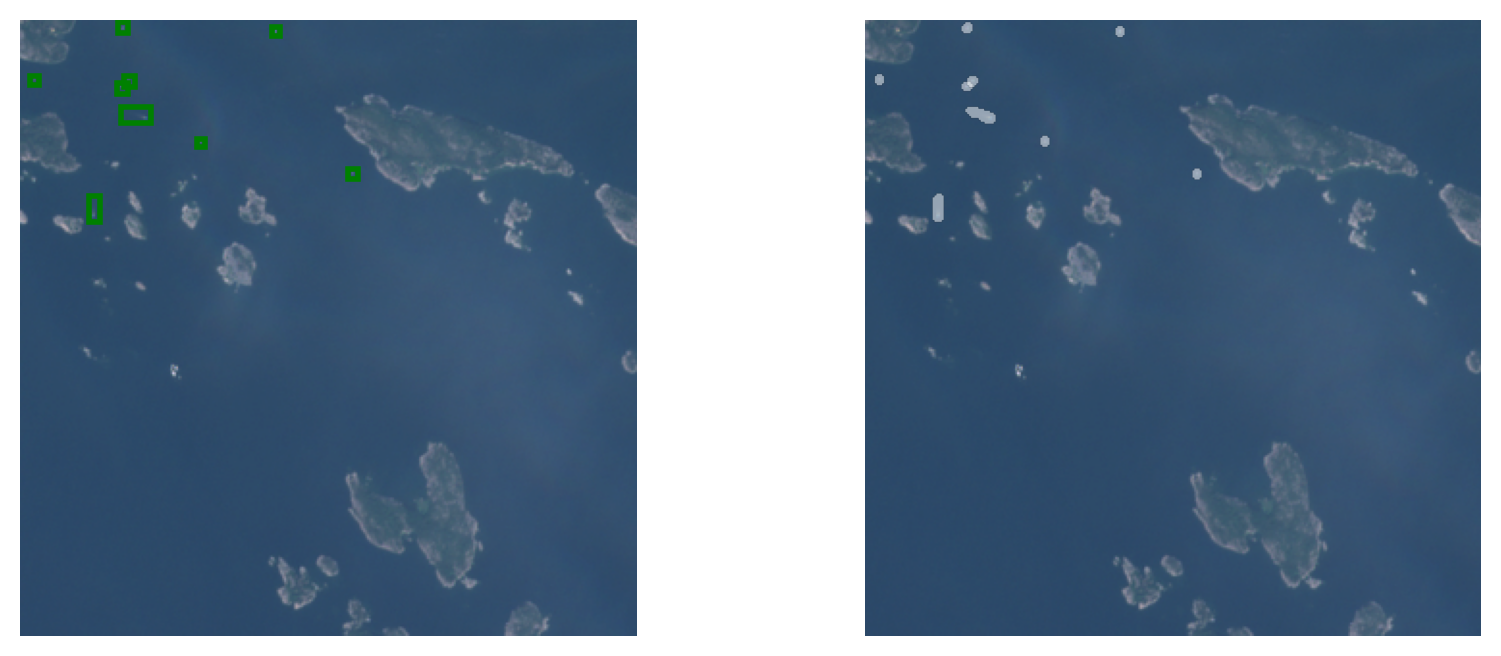

In [ ]:
f, a = plt.subplots(1,2, figsize=(10,4), dpi=200)
a[0].axis('off')
a[0].imshow((im*bright).astype(int))
for box in input_box: show_box(box, a[0])
a[1].axis('off')
a[1].imshow((im*bright).astype(int))
for mask in masks: show_mask(mask.squeeze(0), a[1])


Next step is to convert the data into polygons and georeference them. `rasterio.features.shapes` can create proper polygons that cover all the pixels in the mask and follow the pixel edges.

In [ ]:
from pycococreatortools.pycococreatortools import binary_mask_to_polygon

polys = []

for mask in masks:
    bmask = binary_mask_to_polygon(mask[0])
    xy_coords = [(bmask[0][i], 
                  bmask[0][i+1]) 
                 for i in range(0,len(bmask[0]),2)]
    xy_coords.append(xy_coords[-1])
    polys.append(Polygon(xy_coords))

poly_px_gdf = ex_px_gdf.copy()
poly_px_gdf['geometry'] = polys

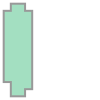

In [ ]:
from rasterio.features import shapes
Polygon((list(shapes(masks[0][0].astype(np.int8)))[0][0])['coordinates'][0])

In [ ]:
polys = []

for mask in masks:
    shape_list = list(shapes(mask[0].astype(np.int8)))
    polys.append(Polygon((list(shapes(mask[0].astype(np.int8)))[0][0])['coordinates'][0]))

poly_px_gdf = ex_px_gdf.copy()
poly_px_gdf['geometry'] = polys

Now only thing that is needed is to georeference these polygons, which can be done with `georegister_px_df` from `geo2ml`:

<Axes: >

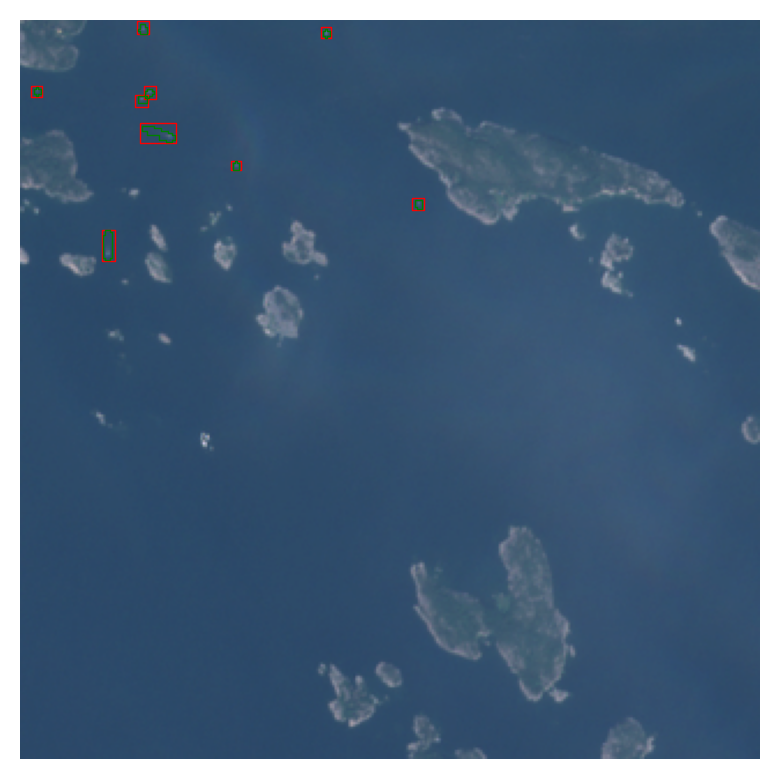

In [ ]:
f, a = plt.subplots(1,1, dpi=200)
a.axis('off')
with rio.open(images_with_anns[im_ix]) as src:
    tfm = src.transform
    im = src.read()
    rioplot.show((im*bright).astype(int), transform=tfm, ax=a)

poly_gdf = georegister_px_df(poly_px_gdf.copy(), images_with_anns[im_ix])
ex_gdf.plot(facecolor='none', ax=a, edgecolor='r', linewidth=.5)
poly_gdf.plot(facecolor='none', ax=a, edgecolor='g', linewidth=.5)

Each file can then be saved to a file. You can loop through all files to create the masks for the dataset. Masks can even further be improved by clipping the masks to be within the bounding boxes. Most likely results will improve by using tightened bounding boxes.

In [ ]:
poly_gdf.to_file(f'example_data/sam2/vectors/{valid_anns[im_ix].name}')